In [4]:
import ultralytics
from ultralytics import YOLO

In [5]:
import cv2 
import numpy as np 
import matplotlib.pyplot as plt 
from PIL import Image 

import warnings 
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')  # Suppress Matplotlib warnings

In [6]:
plt.rcParams["figure.figsize"] = [3.0, 3.0]

# Just import these 2 modules

In [7]:
from yolo_cam.eigen_cam import EigenCAM
from yolo_cam.utils.image import show_cam_on_image, scale_cam_image

In [8]:
# Detect puppies

In [9]:
model = YOLO('models/yolo11n.pt')
model = model.cpu()

In [10]:
img = cv2.imread('images/puppies.jpg')
img = cv2.resize(img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [11]:
target_layers =[model.model.model[-2]]


0: 640x640 3 dogs, 3 bears, 218.7ms
Speed: 6.9ms preprocess, 218.7ms inference, 2.7ms postprocess per image at shape (1, 3, 640, 640)


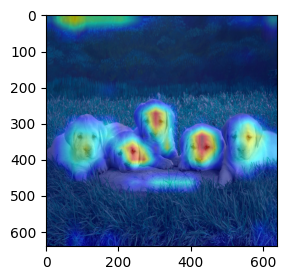

In [12]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)
plt.imshow(cam_image)
plt.show()

In [13]:
model = YOLO('models/drone.pt')
# model = YOLO('models/yolo11x.pt')
model = model.cpu()

In [19]:
origin_img = cv2.imread('images/images/123.jpg')
img = cv2.resize(origin_img, (640, 640))
rgb_img = img.copy()
img = np.float32(img) / 255

In [20]:
target_layers =[model.model.model[-8]]


0: 640x640 41 pedestrians, 5 peoples, 5 bicycles, 36 cars, 4 vans, 2 trucks, 3 tricycles, 3 awning-tricycles, 19 motors, 6101.9ms
Speed: 5.2ms preprocess, 6101.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)


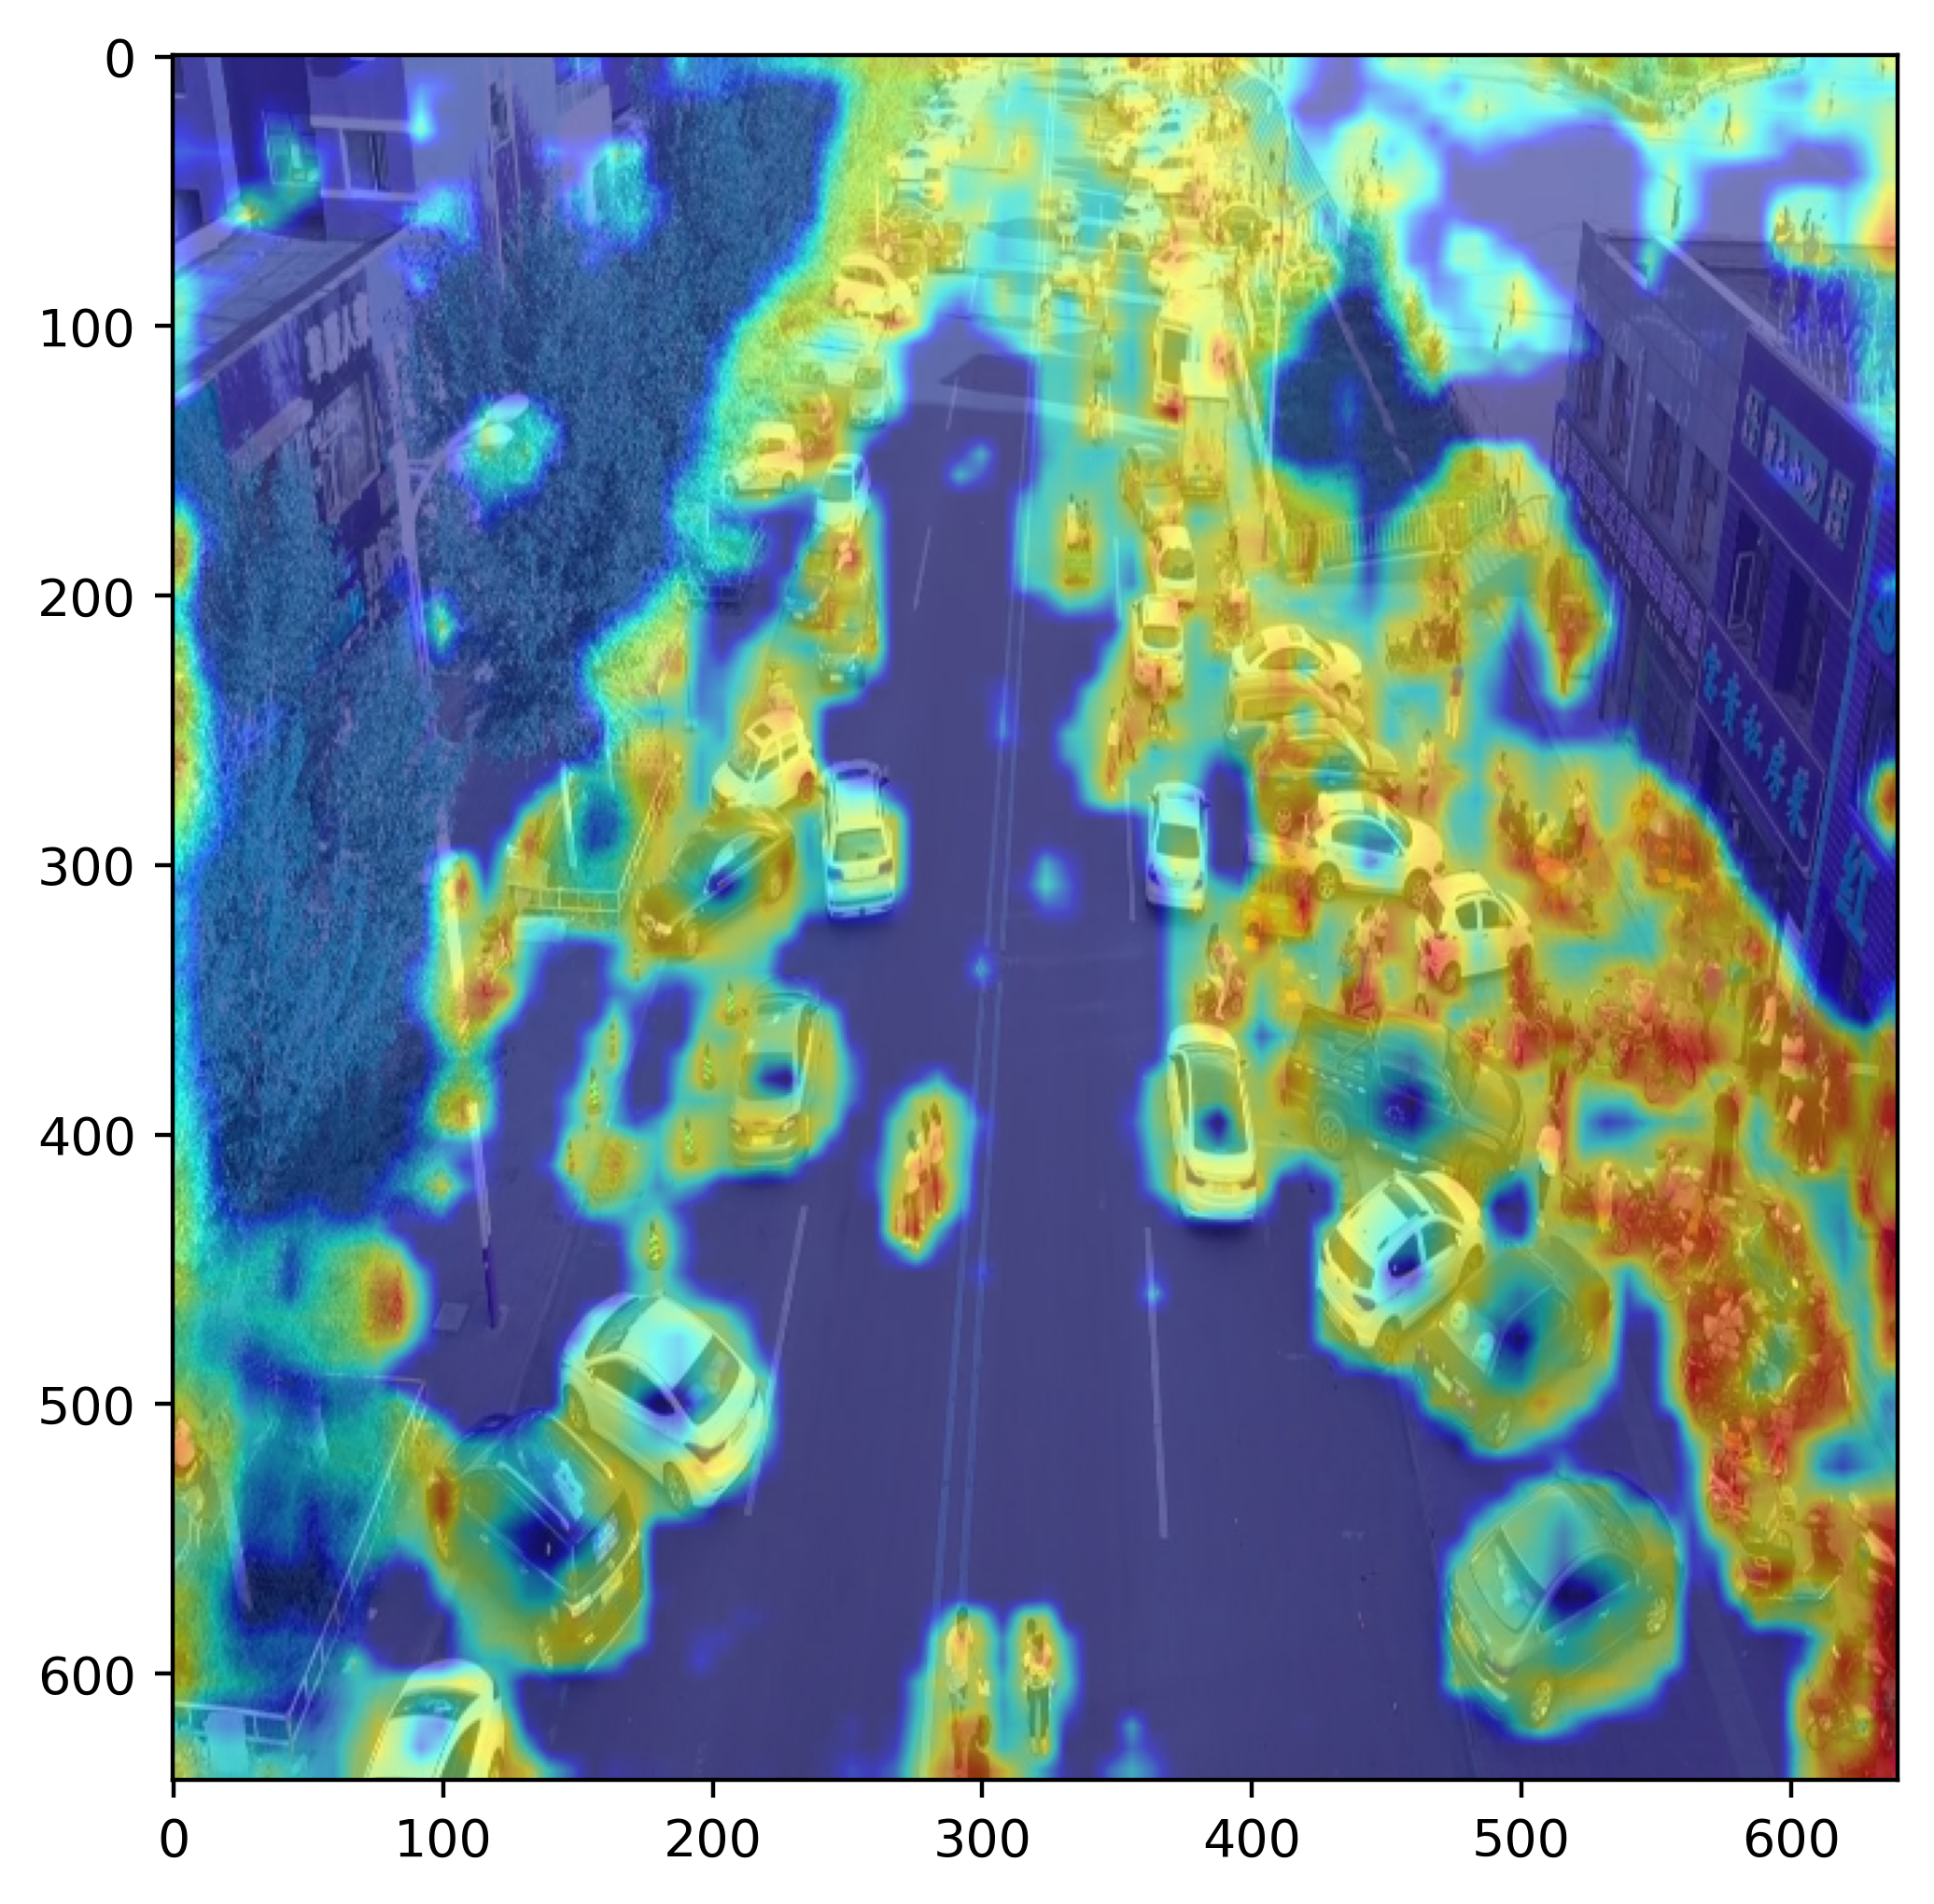

True

In [21]:
cam = EigenCAM(model, target_layers,task='od')
grayscale_cam = cam(rgb_img)[0, :, :]
cam_image = show_cam_on_image(img, grayscale_cam, use_rgb=True)

# Set figure size and DPI
fig = plt.figure(figsize=(6, 6), dpi=400)  # Higher DPI for better resolution
plt.imshow(cam_image)
plt.show()

cv2.imwrite('./3.jpg', cam_image[:,:,[2,1,0]])


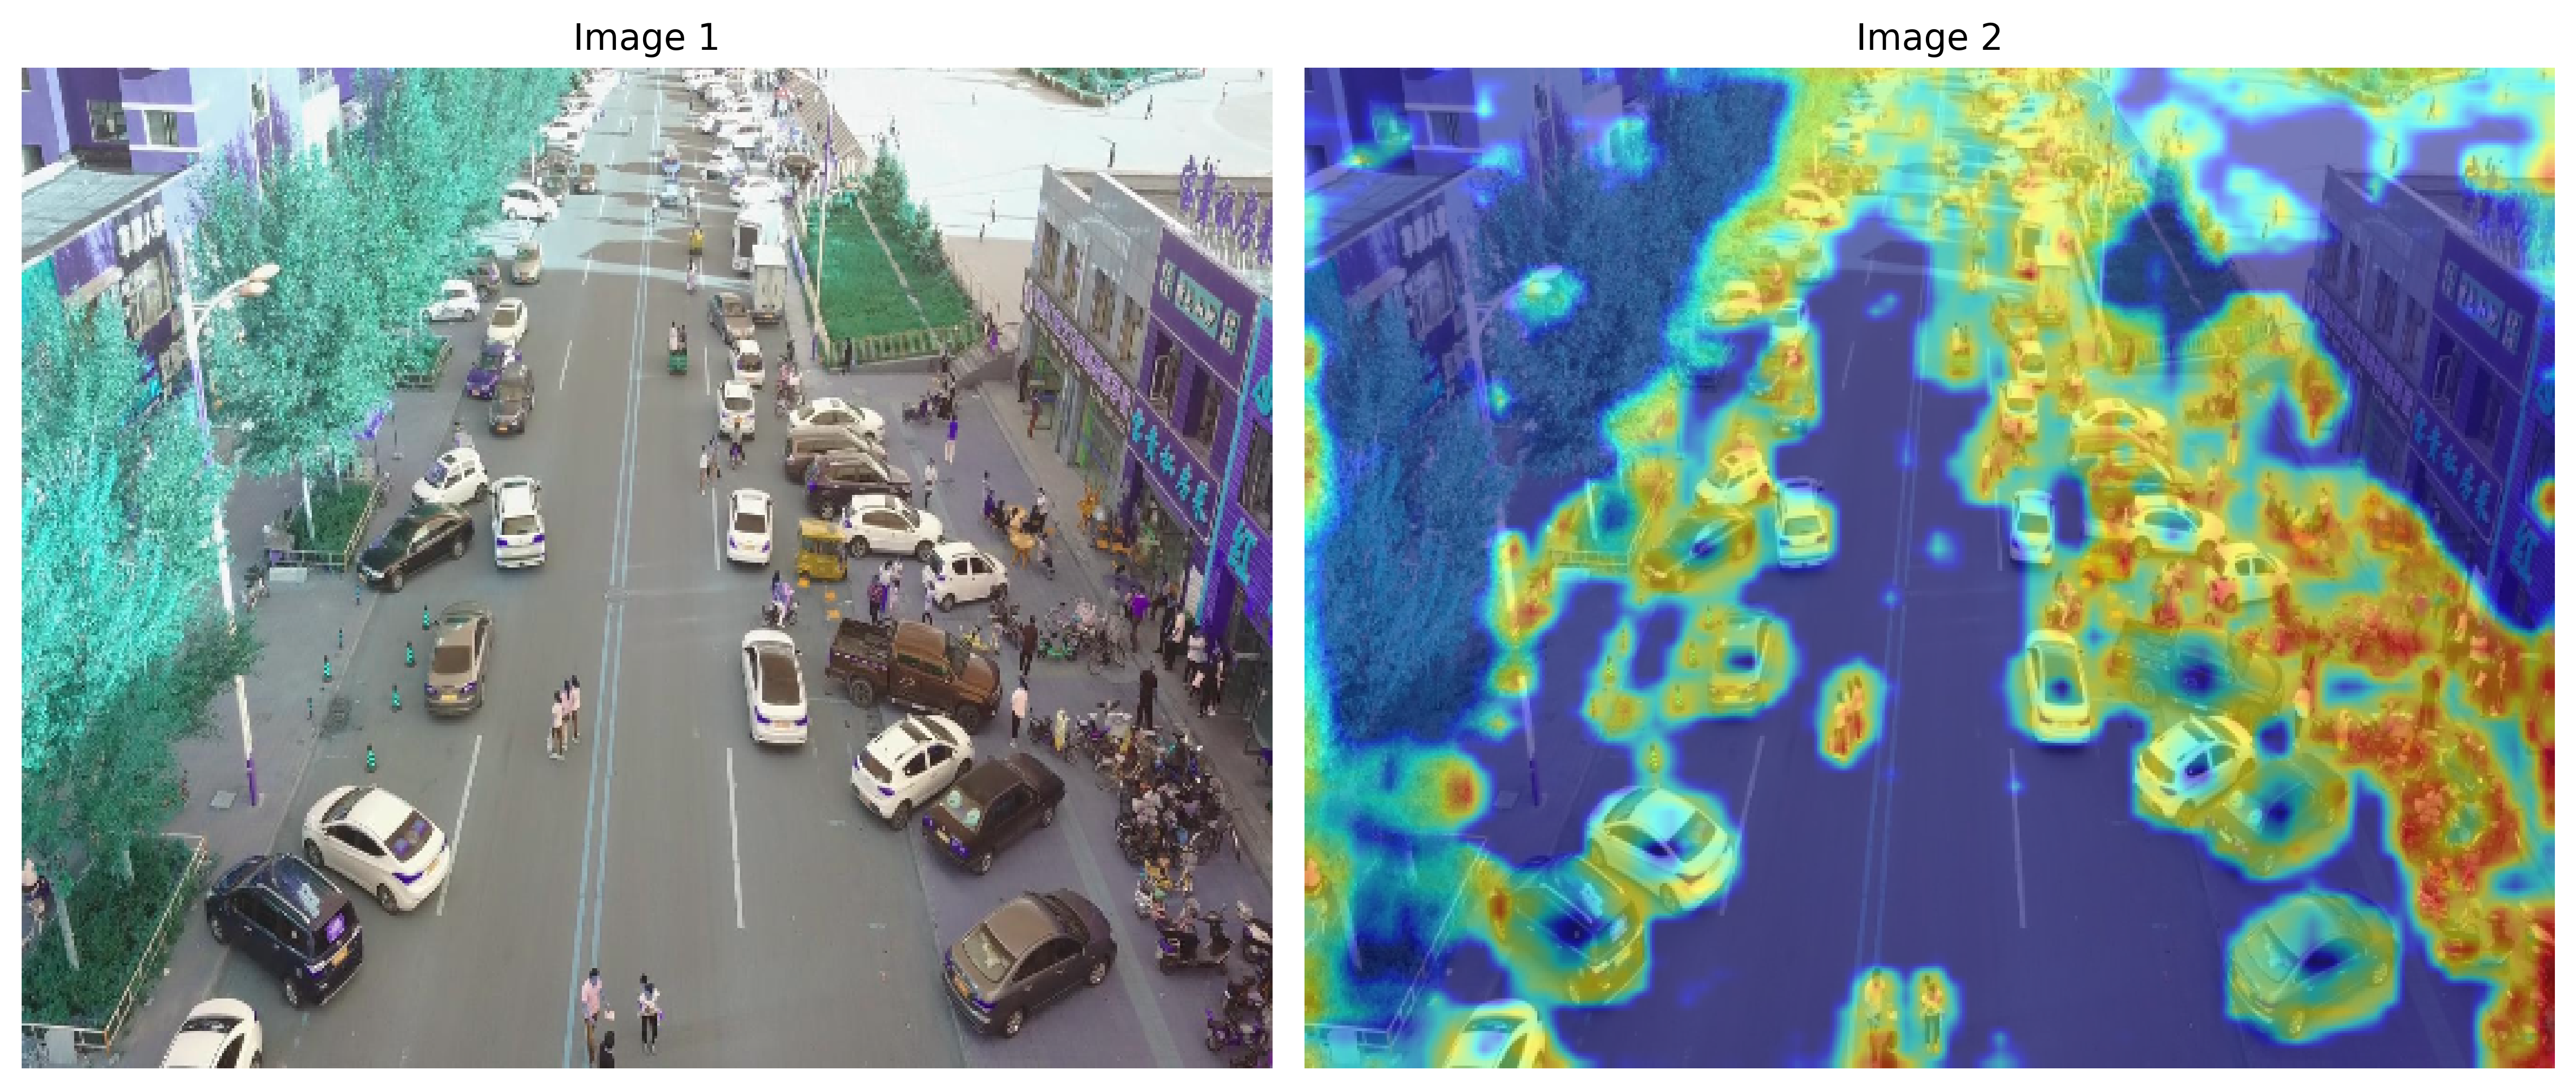

In [26]:
# Load two images
image1 = origin_img
image2 = cam_image

# Resize both images to the same dimensions
new_size = (500, 400)  # Width=400, Height=300
image1 = cv2.resize(image1, new_size)
image2 = cv2.resize(image2, new_size)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=400)

# Display the resized images
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].set_title("origin")

axes[1].imshow(image2)
axes[1].axis('off')
axes[1].set_title("Heat map")

# Adjust spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()

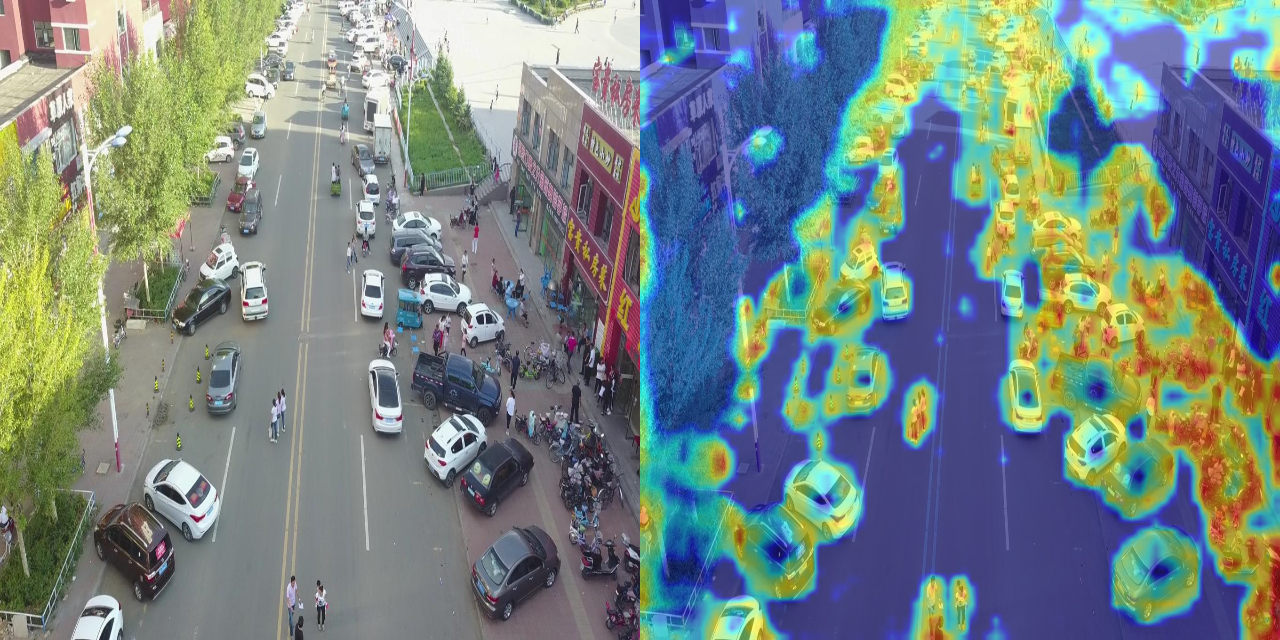

In [29]:
im = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR)
Image.fromarray(np.hstack((im, cam_image)))

In [ ]:
!sz ./3.jpg
!sz ./images/images/23.jpg

�B00000000000000

In [1]:
!ls

3.jpg		      LICENSE.txt  yolo_cam
drone_EigenCAM.ipynb  models	   YOLO_v11_EigenCAM.ipynb
images		      README.md    YOLO_v8n_EigenCAM.ipynb
